# A crash-safe paper-trading loop with full order attribution

The hard part of a live loop is not the strategy. It is answering, a week
later, *"why did we send that order?"*.

This recipe builds a sequential, deterministic paper-trading loop where every
stage is a versioned commit. Each feed chunk is one `append` to `trades`, the
signal is computed in SQL on exactly that head, and every order row **stores
the trades version that produced it**.

Attribution stops being forensics and becomes a join. And because
`h5i('trades', v)` is O(1) time travel, you can replay any order's exact
signal input on demand.

Crash safety comes for free. Every commit is an atomic manifest swap, so a
`kill -9` mid-write leaves the previous head fully consistent, and the loop
restarts by asking the database where the feed stopped.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import h5i_db
from h5i_db import col, count_star, sql_expr, time_bucket

import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_paper"), create=True)

## 1. The data

`cu.make_trades` gives one session of ticks for two names, one row per print.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | trade timestamp, ascending |
| `symbol` | `string` | ticker, `AAPL` or `MSFT` |
| `price` | `float64` | trade price |
| `size` | `int64` | shares traded |
| `exchange` | `string` | reporting venue |
| `side` | `string` | `B` buyer-initiated, `S` seller-initiated |

We chunk it into 5-minute deliveries: a deterministic stand-in for a live feed
handler.

In [2]:
feed = cu.make_trades(symbols=["AAPL", "MSFT"], days=1, trades_per_day=20_000).to_pandas()
print(f"{len(feed):,} rows x {feed.shape[1]} columns")
feed.head()

33,056 rows x 6 columns


,ts,symbol,price,size,exchange,side
0,2026-06-01 13:30:00.230953+00:00,AAPL,265.06,1,NASDAQ,B
1,2026-06-01 13:30:00.283636+00:00,AAPL,265.07,400,NYSE,B
2,2026-06-01 13:30:00.447310+00:00,MSFT,363.04,200,NYSE,B
3,2026-06-01 13:30:00.669981+00:00,AAPL,265.07,1,NASDAQ,B
4,2026-06-01 13:30:00.684128+00:00,MSFT,362.97,1,NYSE,S


## 2. Tables: feed, orders, positions, all append-only

Three pure-append tables. Append-only is not just a style choice. It keeps the
version chain compatible with `tail()` streaming reads, and it makes the order
blotter tamper-evident by construction.

In [3]:
trade_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("price", pa.float64()),
        pa.field("size", pa.int64()),
        pa.field("exchange", pa.string()),
        pa.field("side", pa.string()),
    ]
)
order_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("side", pa.string()),
        pa.field("qty", pa.int64()),
        pa.field("price", pa.float64()),
        pa.field("data_version", pa.int64()),   # trades sequence that produced this order
    ]
)
position_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("position", pa.int64()),
        pa.field("price", pa.float64()),
        pa.field("mkt_value", pa.float64()),
    ]
)
db.create_table("trades", trade_schema, time_column="ts", sort_key=["ts", "symbol"])
db.create_table("orders", order_schema, time_column="ts", sort_key=["ts", "symbol"])
db.create_table("positions", position_schema, time_column="ts", sort_key=["ts", "symbol"])
db.tables()

['orders', 'positions', 'trades']

## 3. The signal

The signal is a fast/slow EWMA crossover on 1-minute closes, computed entirely
in the database against whatever the `trades` head is at that moment.

`time_bucket` builds the bars, `ewma` window functions smooth them, and
`row_number()` picks the latest bar per symbol.

In [4]:
feed["chunk"] = feed["ts"].dt.floor("5min")
chunks = list(feed.groupby("chunk", sort=True))
print(f"{len(feed):,} ticks -> {len(chunks)} five-minute deliveries")

def signal_frame(version=None):
    """Latest fast/slow EWMA crossover per symbol, at any read point."""
    bars = (
        db.table("trades", version=version)
        .group_by(time_bucket("1m", col("ts")).alias("bar"), "symbol")
        .agg(close=col("price").last("ts"))
    )
    return (
        bars.with_columns(
            fast=col("close").ewma(0.30, order_by="bar", partition_by="symbol"),
            slow=col("close").ewma(0.05, order_by="bar", partition_by="symbol"),
        )
        .with_columns(
            rn=sql_expr("row_number()").over(
                partition_by="symbol", order_by="bar", descending=True
            )
        )
        .filter(col("rn") == 1)
        .select("symbol", "close", "fast", "slow")
        .sort("symbol")
    )

33,056 ticks -> 78 five-minute deliveries


## 4. The event loop: append chunk, signal, append orders, mark

Sequential and deterministic, with no threads and no sleeps.

Per chunk there is one commit for the ticks, one signal query on that exact
head, at most one commit for orders as a batch rather than per row, and one
for the marks. The commit dict returned by `append` hands us the sequence
number we stamp on each order.

The long/flat logic is simple: fast above slow means hold 100 shares,
otherwise flat.

In [5]:
TARGET = 100
pos = {"AAPL": 0, "MSFT": 0}
cash = 0.0
equity_track = []

for chunk_ts, chunk in chunks:
    data = pa.Table.from_pandas(
        chunk.drop(columns="chunk").sort_values(["ts", "symbol"]),
        schema=trade_schema, preserve_index=False,
    )
    commit = db.append("trades", data)
    seq = commit["sequence"]

    sig = signal_frame().to_pandas().set_index("symbol")
    mark_ts = chunk_ts + pd.Timedelta(minutes=5)

    order_rows = []
    for sym, row in sig.iterrows():
        desired = TARGET if row["fast"] > row["slow"] else 0
        delta = desired - pos[sym]
        if delta != 0:
            order_rows.append(
                {"ts": mark_ts, "symbol": sym, "side": "BUY" if delta > 0 else "SELL",
                 "qty": abs(delta), "price": row["close"], "data_version": seq}
            )
            cash -= delta * row["close"]
            pos[sym] = desired
    if order_rows:
        db.append("orders", pa.Table.from_pandas(
            pd.DataFrame(order_rows).sort_values(["ts", "symbol"]),
            schema=order_schema, preserve_index=False))

    marks = pd.DataFrame(
        {"ts": mark_ts, "symbol": list(sig.index),
         "position": [pos[s] for s in sig.index],
         "price": sig["close"].to_numpy(),
         "mkt_value": [pos[s] * sig.loc[s, "close"] for s in sig.index]}
    )
    db.append("positions", pa.Table.from_pandas(
        marks.sort_values(["ts", "symbol"]), schema=position_schema, preserve_index=False))
    equity_track.append((mark_ts, cash + marks["mkt_value"].sum()))

n_orders = db.table("orders").select(count_star().alias("n")).to_pandas()["n"].iloc[0]
print(f"loop done: {len(chunks)} chunks, {n_orders} orders, "
      f"final positions {pos}, final equity {equity_track[-1][1]:,.2f} USD")

loop done: 78 chunks, 29 orders, final positions {'AAPL': 0, 'MSFT': 100}, final equity -110.00 USD


## 5. Restart recovery: the database is the checkpoint

If the process dies anywhere in the loop, no partial state exists. Each commit
either fully happened or did not.

On restart, the resume point is a query rather than a checkpoint file that
might itself be stale.

In [6]:
resume = db.table("trades").select(
    last_tick=col("ts").max(), rows_ingested=count_star()
).to_pandas()
print("on restart, continue the feed after:")
resume

on restart, continue the feed after:


,last_tick,rows_ingested
0,2026-06-01 19:59:59.826233+00:00,33056


## 6. Order attribution: replay the exact signal input

Every order carries `data_version`. To audit one, point the *same* signal
frame at that version, which is O(1) time travel to the head the loop saw, and
confirm the decision.

This is the difference between "we think the signal said buy" and "here is the
signal, recomputed from the exact bytes, saying buy".

In [7]:
last_order = (
    db.table("orders")
    .select("ts", "symbol", "side", "qty", "price", "data_version")
    .sort("ts", descending=True)
    .limit(1)
    .to_pandas()
    .iloc[0]
)
print("auditing order:", dict(last_order))

replayed = (
    signal_frame(version=int(last_order["data_version"]))
    .to_pandas()
    .set_index("symbol")
)
row = replayed.loc[last_order["symbol"]]
replayed_desired = TARGET if row["fast"] > row["slow"] else 0

held_after = (
    db.table("positions")
    .filter(col("symbol") == last_order["symbol"], col("ts") == last_order["ts"].isoformat())
    .select("position")
    .to_pandas()["position"]
    .iloc[0]
)

print(f"replayed signal at v{int(last_order['data_version'])}: "
      f"fast={row['fast']:.4f} slow={row['slow']:.4f} -> desired position {replayed_desired}")
assert replayed_desired == held_after, "replayed decision must match the recorded position"
print(f"recorded position after order: {held_after} - attribution verified")

auditing order: {'ts': Timestamp('2026-06-01 20:00:00+0000', tz='UTC'), 'symbol': 'AAPL', 'side': 'SELL', 'qty': np.int64(100), 'price': np.float64(266.21), 'data_version': np.int64(78)}
replayed signal at v78: fast=266.3084 slow=266.4002 -> desired position 0
recorded position after order: 0 - attribution verified


## 7. The reader side: streaming new orders with `tail()`

A downstream consumer, whether risk checks or an execution bridge, follows the
order blotter with `tail('orders', after_version, poll_ms)`.

Two production rules apply. `tail` requires a **pure-append** version chain,
so any write, delete, restore or compact in the range errors out. That is one
reason our blotter is append-only.

And `tail` is **unbounded**. It blocks until `LIMIT` rows have arrived, so
always attach a LIMIT no larger than what you know is there, or a query
timeout.

In [8]:
overs = db.versions("orders")
after = overs[max(0, len(overs) - 6)]          # start ~5 commits behind head
available = overs[-1]["rows"] - after["rows"]
n = int(min(10, available))
print(f"tailing orders after v{after['sequence']} ({available} new rows, reading {n}):")
db.sql(f"SELECT * FROM tail('orders', {after['sequence']}, 50) LIMIT {n}",
       timeout=30).to_pandas()

tailing orders after v23 (5 new rows, reading 5):


,ts,symbol,side,qty,price,data_version
0,2026-06-01 19:25:00+00:00,MSFT,BUY,100,362.31,71
1,2026-06-01 19:40:00+00:00,MSFT,SELL,100,361.05,74
2,2026-06-01 19:45:00+00:00,AAPL,BUY,100,266.43,75
3,2026-06-01 19:55:00+00:00,MSFT,BUY,100,362.37,77
4,2026-06-01 20:00:00+00:00,AAPL,SELL,100,266.21,78


## 8. Session wrap-up: equity curve and blotter hygiene

The equity curve comes from the recorded marks.

Then maintenance. A day of 5-minute commits leaves roughly 78 small segments
per table, so `compact()` merges them, as its own audited commit.

Note the trade-off: a compact commit breaks the pure-append chain for `tail()`
ranges that span it, so compact *behind* your consumers' read positions.

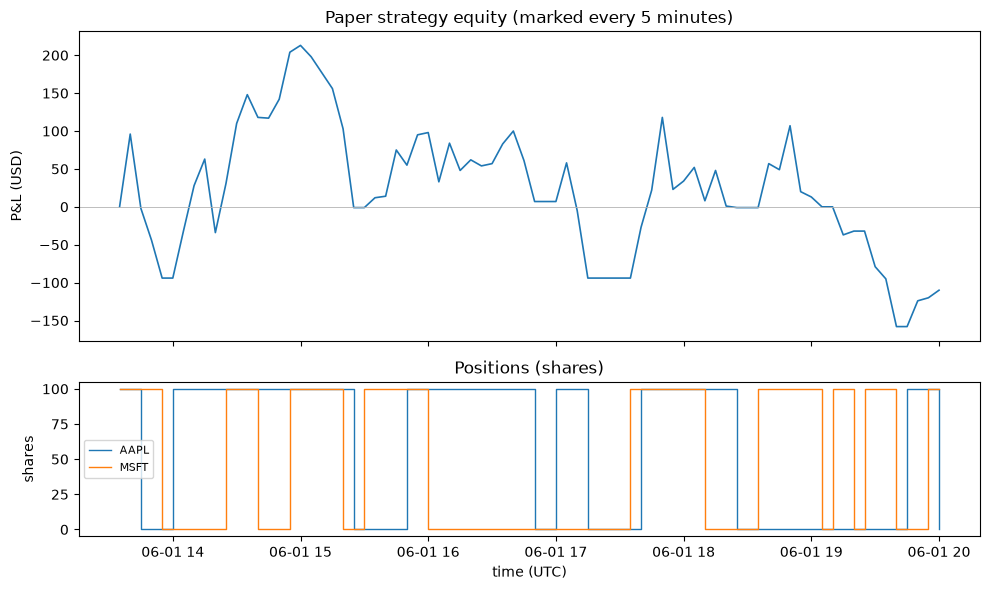

In [9]:
import matplotlib.pyplot as plt

eq = pd.DataFrame(equity_track, columns=["ts", "equity"]).set_index("ts")
posn = (
    db.table("positions")
    .select("ts", "symbol", "position")
    .sort("ts")
    .to_pandas()
    .pivot(index="ts", columns="symbol", values="position")
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.plot(eq.index, eq["equity"], lw=1.2, color="tab:blue")
ax1.axhline(0, color="0.7", lw=0.6)
ax1.set_title("Paper strategy equity (marked every 5 minutes)")
ax1.set_ylabel("P&L (USD)")
for sym in posn.columns:
    ax2.step(posn.index, posn[sym], where="post", label=sym, lw=1.0)
ax2.set_title("Positions (shares)")
ax2.set_xlabel("time (UTC)")
ax2.set_ylabel("shares")
ax2.legend(fontsize=8)
fig.tight_layout()

In [10]:
for t in ("trades", "orders", "positions"):
    before = db.versions(t)[-1]["segments"]
    c = db.compact(t, note="post-session compaction")
    print(f"{t}: {before} segments -> {c['segments_total']} (v{c['sequence']}, op={c['op']})")

trades: 78 segments -> 1 (v79, op=compact)
orders: 28 segments -> 1 (v29, op=compact)
positions: 78 segments -> 1 (v79, op=compact)


## Takeaways

- One chunk is one commit. The commit's sequence number stamped into each
  order row makes attribution a join, and replay a `h5i('trades', v)` query.
- Atomic commits are the crash-safety story. `kill -9` mid-write leaves the
  previous head intact, and the restart point is `SELECT max(ts)`. The
  database is the checkpoint.
- Keep the blotter pure-append. It stays `tail()`-compatible for downstream
  consumers and tamper-evident for auditors. Always LIMIT a `tail()` read, and
  ideally give it a timeout, because it blocks until enough rows arrive.
- Batch orders per cycle rather than committing per row, and `compact()` after
  the session, behind your readers, to merge the day's small segments.

In [11]:
db.close()